# Notebook prêt à compléter
Ce notebook sert de support au projet TensorFlow texte + tabulaire.

# Notebook 1 - Analyse exploratoire des données

## Objectif
Ce notebook a pour objectif d'explorer le dataset de tickets support afin de comprendre sa structure, la qualité des données, la distribution des variables et les cibles métier potentielles.

## Contexte métier
Le projet vise deux tâches :
- prédire la priorité d'un ticket (`Low`, `Medium`, `High`, `Critical`) ;
- prédire une catégorie de routage métier comme `retour_produit` ou `support_technique`.

L'analyse exploratoire permet de préparer les choix de preprocessing et de modélisation.

In [2]:
# Import des bibliothèques principales pour l'analyse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Option d'affichage pour mieux lire les colonnes
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [3]:
# Chargement du dataset brut
df = pd.read_csv("../data/raw/customer_support_tickets.csv")

# Affichage des premières lignes
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
# Dimensions du dataset : nombre de lignes et de colonnes
print("Shape du dataset :", df.shape)

# Informations générales sur les colonnes
df.info()

Shape du dataset : (8469, 17)
<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null

In [5]:
# Liste des colonnes
print("Colonnes disponibles :")
for col in df.columns:
    print("-", col)

Colonnes disponibles :
- Ticket ID
- Customer Name
- Customer Email
- Customer Age
- Customer Gender
- Product Purchased
- Date of Purchase
- Ticket Type
- Ticket Subject
- Ticket Description
- Ticket Status
- Resolution
- Ticket Priority
- Ticket Channel
- First Response Time
- Time to Resolution
- Customer Satisfaction Rating


In [8]:
# Vérification des valeurs manquantes
missing = df.isnull().sum().sort_values(ascending=False)
# Vérification des valeurs manquantes
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Customer Satisfaction Rating    5700
Resolution                      5700
Time to Resolution              5700
First Response Time             2819
dtype: int64

In [9]:
# Vérification des doublons
print("Nombre de doublons :", df.duplicated().sum())

Nombre de doublons : 0


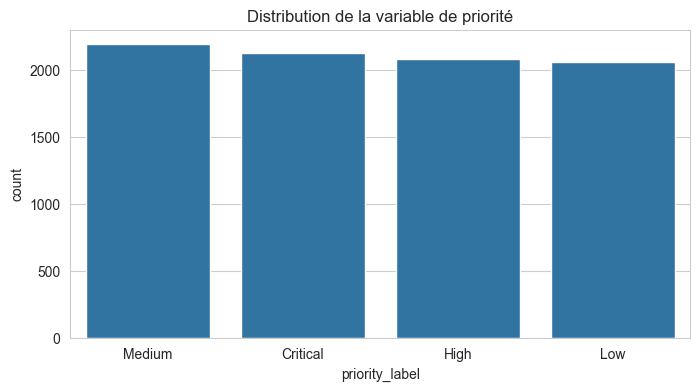

In [26]:
# Distribution de la variable de priorité
plt.figure(figsize=(8, 4))
col_name = "Ticket Priority" if "Ticket Priority" in df.columns else "priority_label"
sns.countplot(data=df, x=col_name, order=df[col_name].value_counts().index)
plt.title("Distribution de la variable de priorité")
plt.xticks(rotation=0)
plt.show()

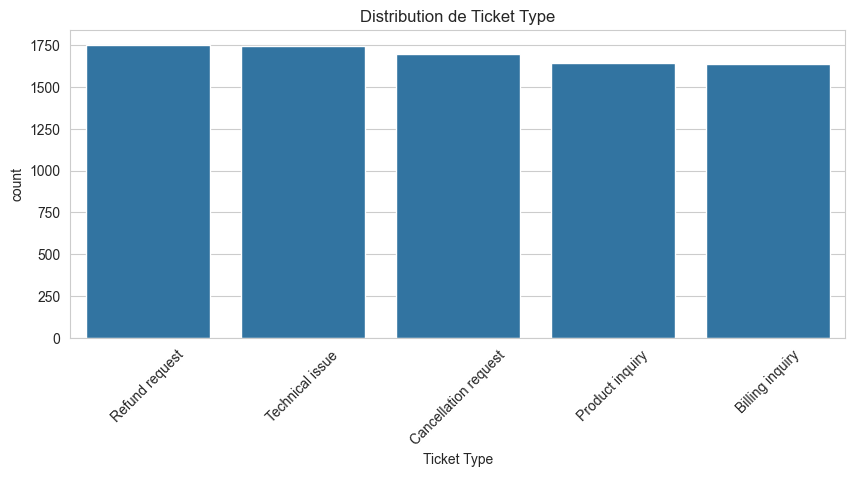

In [21]:
# Distribution de Ticket Type
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="Ticket Type", order=df["Ticket Type"].value_counts().index)
plt.title("Distribution de Ticket Type")
plt.xticks(rotation=45)
plt.show()

In [25]:
# Création de variables de longueur de texte pour étudier la richesse textuelle

if "Ticket Subject" in df.columns:
    df["subject_length"] = df["Ticket Subject"].astype(str).apply(len)
else:
    df["subject_length"] = df["text"].astype(str).apply(len)

if "Ticket Description" in df.columns:
    df["description_length"] = df["Ticket Description"].astype(str).apply(len)
else:
    df["description_length"] = df["text"].astype(str).apply(len)

# Affichage des statistiques descriptives
df[["subject_length", "description_length"]].describe()
# Création de variables de longueur de texte pour étudier la richesse textuelle
if "Ticket Subject" in df.columns:
    df["subject_length"] = df["Ticket Subject"].astype(str).apply(len)
else:
    df["subject_length"] = df["text"].astype(str).apply(len)

if "Ticket Description" in df.columns:
    df["description_length"] = df["Ticket Description"].astype(str).apply(len)
else:
    df["description_length"] = df["text"].astype(str).apply(len)

# Affichage des statistiques descriptives
df[["subject_length", "description_length"]].describe()

# Affichage des statistiques descriptives
df[["subject_length", "description_length"]].describe()

,subject_length,description_length
count,8469.000000,8469.000000
mean,293.439721,293.439721
std,43.837927,43.837927
min,156.000000,156.000000
25%,274.000000,274.000000
50%,302.000000,302.000000
75%,323.000000,323.000000
max,399.000000,399.000000


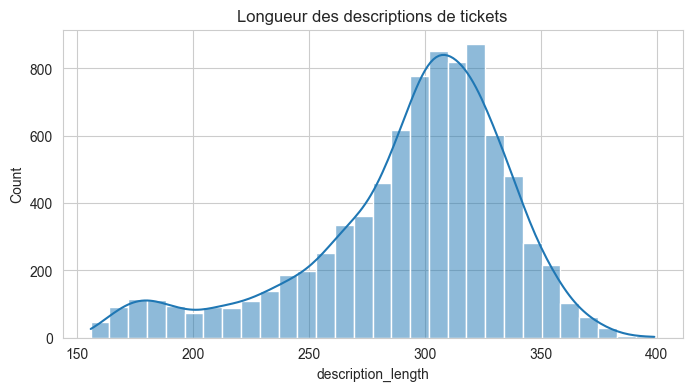

In [27]:
# Visualisation de la longueur des descriptions
plt.figure(figsize=(8, 4))
sns.histplot(df["description_length"], bins=30, kde=True)
plt.title("Longueur des descriptions de tickets")
plt.show()

In [29]:
# Affichage de quelques exemples de tickets
cols = [c for c in ["Ticket Subject", "Ticket Description", "Ticket Type", "Ticket Priority"] if c in df.columns]
df[cols].sample(5, random_state=42) if cols else df.sample(5, random_state=42)

,Ticket Type
4830,Refund request
7075,Product inquiry
4715,Billing inquiry
2022,Billing inquiry
676,Refund request


## Conclusion de l'analyse exploratoire

L'analyse exploratoire montre que le dataset contient :
- des variables textuelles utiles pour comprendre la demande du client ;
- des variables tabulaires apportant un contexte supplémentaire ;
- une cible directe pour la priorité ;
- une variable `Ticket Type` exploitable pour construire une cible de routage.

La prochaine étape consiste à nettoyer les données et à construire un dataset prêt pour l'entraînement.